# 03 · LangGraph: el agente que planifica y recuerda

**Python que piensa: agentes de analítica con LangChain y LangGraph**
Sociedad Ecuatoriana de Estadística · Semana de Python

---

1. **`create_agent`**: el bucle del agente, ya hecho. El modelo decide cuántas
   consultas necesita.
2. **Un hilo de conversación**: sobre el costo **ambulatorio**, abrimos el
   análisis pieza por pieza. Cada paso usa lo que se encontró en el anterior.

> **Sobre los datos.** Reclamos médicos **sintéticos** del CMS de Estados
> Unidos. Sirven para construir herramientas, no para inferir sobre la población
> real de Medicare.

## Legibilidad para proyección

In [1]:
from IPython.display import HTML, display

# Agranda la letra de las salidas para que se lea desde el fondo de la sala.
display(HTML("""
<style>
  .jp-RenderedText pre, .jp-OutputArea-output pre, div.output_area pre {
      font-size: 15px !important; line-height: 1.5 !important; }
  .jp-RenderedHTMLCommon table { font-size: 15px !important; }
  .jp-InputArea-editor, .CodeMirror { font-size: 15px !important; }
</style>
"""))
print("Tipografía ajustada para proyección.")

Tipografía ajustada para proyección.


## Dónde estamos, credenciales y modelo

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "datos").is_dir()), None)
BASE = RAIZ / "datos" / "reclamos.db"                      # la base SQLite
DICCIONARIO = RAIZ / "datos" / "diccionario_sabana.yaml"   # lo que el agente debe saber de la tabla
load_dotenv(RAIZ / ".env")                                 # las credenciales (ver notebook 01)

# El mismo modelo del notebook 02: gpt-4.1 en Azure AI Foundry.
foundry = ChatOpenAI(
    base_url=os.environ["AZURE_OPENAI_BASE_URL"],   # a dónde llamar
    api_key=os.environ["AZURE_OPENAI_API_KEY"],     # quién llama
    model=os.environ["AZURE_OPENAI_MODELO"],        # qué modelo
    temperature=0,                                  # para SQL: siempre la respuesta más probable
)
print("Modelo de trabajo: Foundry ·", foundry.model_name)

Modelo de trabajo: Foundry · gpt-4.1


## Lo que cuesta cada pregunta

Precio oficial de gpt-4.1 por millón de tokens, consultado el 2026-10-07
([OpenAI](https://developers.openai.com/api/docs/models/gpt-4.1),
[Azure](https://azure.microsoft.com/es-es/pricing/details/azure-openai)):
entrada **2,00**, entrada leída de caché **0,50**, salida **8,00**.

In [3]:
# USD por MILLÓN de tokens. Si el proveedor cambia sus precios, se cambia aquí.
PRECIO = {"entrada": 2.00, "cache_lectura": 0.50, "salida": 8.00}
gasto_total = 0.0    # lo que llevamos gastado en este notebook, en USD

# Se usa después de CADA llamada: lee la cuenta de tokens y la multiplica por el precio.
def costo(respuesta, proveedor):
    global gasto_total
    modelo_usado = respuesta.response_metadata["model_name"]    # el modelo que respondió

    uso = respuesta.usage_metadata                              # la cuenta de tokens de esta respuesta
    leidos_de_cache = uso["input_token_details"].get("cache_read", 0)   # entrada que ya estaba en caché
    entrada_normal = uso["input_tokens"] - leidos_de_cache

    usd = (entrada_normal  * PRECIO["entrada"]
         + leidos_de_cache * PRECIO["cache_lectura"]
         + uso["output_tokens"] * PRECIO["salida"]) / 1_000_000
    gasto_total += usd

    print(f"   [{proveedor} · {modelo_usado}] {uso['input_tokens']} tokens de entrada "
          f"({leidos_de_cache} de caché), {uso['output_tokens']} de salida "
          f"-> USD {usd:.6f} | acumulado USD {gasto_total:.6f}")
    return usd

## El diccionario y la tool

Lo mismo del notebook 02, con dos cambios: ahora entran también los ejemplos
**comparativos** (dos años en un SQL con `CASE WHEN`), y la tool devuelve los
**nombres de las columnas** junto con las filas, para que el modelo sepa qué es
cada número.

In [4]:
import json
import sqlite3
import yaml
from langchain_core.tools import tool

diccionario = yaml.safe_load(DICCIONARIO.read_text(encoding="utf-8"))
# En este notebook se activan los ejemplos hasta el nivel "03": básicos y comparativos.
diccionario["consultas_ejemplo"] = [e for e in diccionario["consultas_ejemplo"]
                                    if e["activa_desde"] <= "03"]
contexto = yaml.dump(diccionario, allow_unicode=True, sort_keys=False)

@tool
def ejecutar_sql(sql: str) -> str:
    """Ejecuta una consulta SQL de solo lectura sobre la tabla sabana (SQLite) y devuelve columnas y filas."""
    conexion = sqlite3.connect(BASE.as_uri() + "?mode=ro", uri=True)   # ro = solo lectura
    cursor = conexion.execute(sql)
    columnas = [c[0] for c in cursor.description]    # los nombres de las columnas del resultado
    filas = cursor.fetchall()
    conexion.close()
    return json.dumps({"columnas": columnas, "filas": filas}, ensure_ascii=False)

print(f"Consultas de ejemplo activas: {len(diccionario['consultas_ejemplo'])}")

Consultas de ejemplo activas: 17


## Las instrucciones del agente

In [5]:
# Las reglas de trabajo. Van ANTES del diccionario: así el inicio del prompt es
# siempre igual y la caché lo aprovecha (notebook 02).
instrucciones = """Eres un analista de siniestralidad. Respondes con datos de la tabla sabana usando la tool ejecutar_sql.
Reglas:
- Antes de responder, decide qué consultas necesitas y ejecútalas todas (puedes hacer varias).
- Toda cifra y toda variación se calcula en SQL (usa CASE WHEN para poner 2008 y 2009 lado a lado). No hagas cuentas de memoria.
- No cites ninguna cifra que no haya salido de una consulta.
- Responde solo con las aperturas que se piden. No agregues cruces que nadie pidió.
- "Mayor variación": primero, la apertura con mayor rango (variación más alta menos la más baja);
  dentro de ella, el grupo cuya variación más se aleja de la variación general.
- Para contar reclamos de un año usa sum(anio = 2008) y sum(anio = 2009), nunca count(*) sin filtrar.
- Si un grupo tiene menos de 100 reclamos en un año, advierte que su variación es poco confiable.
- Declara qué definición de costo usaste.

"""
print(f"Instrucciones: {len(instrucciones):,} caracteres | diccionario: {len(contexto):,} caracteres")

Instrucciones: 902 caracteres | diccionario: 17,908 caracteres


---

# Parte 1 · `create_agent`: el bucle, ya hecho

En el notebook 01 escribimos el agente a mano: un `while` que pregunta al modelo,
ejecuta la tool si la pide, y vuelve a preguntar. `create_agent` **es ese mismo
bucle**, construido con LangGraph. Le das el modelo y las tools; el modelo decide
qué consultar, **cuántas veces**, y cuándo terminar.

Le agregamos además un **checkpointer**: la memoria. Guarda la conversación de
cada **hilo** (`thread_id`) para que la siguiente pregunta pueda usar lo anterior.

In [6]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agente = create_agent(
    foundry,                                    # quién decide
    tools=[ejecutar_sql],                       # qué puede usar
    system_prompt=instrucciones + contexto,     # cómo debe trabajar y qué sabe de la tabla
    checkpointer=InMemorySaver(),               # la memoria: guarda cada hilo de conversación
)

# El hilo de esta conversación. Todo invoke con este thread_id la continúa.
hilo = {"configurable": {"thread_id": "ambulatorio"}}
print(type(agente).__name__, "| hilo:", hilo["configurable"]["thread_id"])

CompiledStateGraph | hilo: ambulatorio


## Por dentro: dos nodos y un ciclo

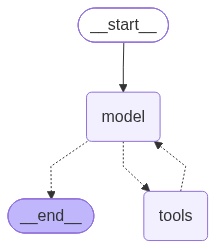

In [7]:
from IPython.display import Image

# El grafo que armó create_agent: el modelo decide; si pide una tool, se ejecuta y
# vuelve al modelo. Cuando ya no pide nada, termina. Ese ciclo ES el agente.
try:
    display(Image(agente.get_graph().draw_mermaid_png()))   # dibujo (usa internet)
except Exception:
    print(agente.get_graph().draw_mermaid())                # respaldo en texto

### Cómo mostramos cada paso

Cada `invoke` devuelve **toda** la conversación del hilo. Para ver solo lo nuevo,
contamos cuántos mensajes había antes. Esta función solo **imprime**: los SQL
que pidió, el costo de cada llamada y la respuesta. No toca al agente.

In [8]:
import textwrap

def mostrar_turno(salida, mensajes_antes):
    nuevos = salida["messages"][mensajes_antes:]          # solo lo que pasó en este paso
    for mensaje in nuevos:
        if mensaje.type == "ai":
            for pedido in mensaje.tool_calls:
                print("El modelo pide:", " ".join(pedido["args"]["sql"].split())[:110], "...")
            usd = costo(mensaje, "Foundry")
    consultas = sum(len(m.tool_calls) for m in nuevos if m.type == "ai")
    print(f"\nConsultas en este paso: {consultas} | mensajes en el hilo: {len(salida['messages'])}\n")
    print("Agente:\n")
    print("\n".join(textwrap.fill(linea, 90) for linea in nuevos[-1].text.splitlines()))

---

# Parte 2 · Abriendo el análisis, pieza por pieza

Una sola conversación sobre el costo **ambulatorio**. Cada pregunta es corta,
porque **el hilo recuerda** lo que se encontró antes:

1. **El panorama**: ¿cuánto cambió, en general, por sexo y por raza?
2. **Abrir** donde está la mayor variación, por grupo etario.
3. **Abrir otra vez**: dentro de ese grupo etario, ¿en qué enfermedades?
4. **El hallazgo** para un gerente.

## Paso 1 · El panorama: general, por sexo y por raza

In [9]:
pregunta = ("¿Cómo cambió el costo ambulatorio de 2008 a 2009? Dame la variación general, "
            "la variación por sexo y la variación por raza, cada una por separado, "
            "y dime dónde está la mayor variación.")

# get_state lee lo que el checkpointer tiene guardado para ese hilo (al inicio, nada).
antes = len(agente.get_state(hilo).values.get("messages", []))
salida = agente.invoke({"messages": [("user", pregunta)]}, hilo)
mostrar_turno(salida, antes)

El modelo pide: SELECT sum(CASE WHEN anio = 2008 THEN monto_pagado ELSE 0 END) AS pagado_2008, sum(CASE WHEN anio = 2009 THEN  ...
El modelo pide: SELECT sexo, sum(CASE WHEN anio = 2008 THEN monto_pagado ELSE 0 END) AS pagado_2008, sum(CASE WHEN anio = 2009 ...
El modelo pide: SELECT raza, sum(CASE WHEN anio = 2008 THEN monto_pagado ELSE 0 END) AS pagado_2008, sum(CASE WHEN anio = 2009 ...
   [Foundry · gpt-4.1-2025-04-14] 5802 tokens de entrada (5632 de caché), 472 de salida -> USD 0.006932 | acumulado USD 0.006932
   [Foundry · gpt-4.1-2025-04-14] 6536 tokens de entrada (6528 de caché), 758 de salida -> USD 0.009344 | acumulado USD 0.016276

Consultas en este paso: 3 | mensajes en el hilo: 6

Agente:

Respuesta basada en monto_pagado (lo que pagó la aseguradora).

Variación general del costo ambulatorio:
- 2008: 78 449 490
- 2009: 94 184 290
- Variación: +20,1 %

Variación por sexo:
- Femenino: 45 830 110 → 54 452 370 (+18,8 %)
- Masculino: 32 619 380 → 39 731 920 (+21,8 %)

Variació

### Lo que hizo solo

Nadie le dijo cuántas consultas hacer: **leyó la pregunta, planificó y ejecutó**
las que necesitaba, calculó las variaciones en SQL y comparó los rangos. Eso es
lo que la cadena del notebook 02 no podía: dar más de una vuelta.

## Paso 2 · Abrir donde está la mayor variación

La pregunta no dice *qué* abrir: "donde está la mayor variación" lo sabe por el
paso 1, que está guardado en el hilo.

In [10]:
# No repetimos nada: "donde está la mayor variación" lo sabe por la memoria del hilo.
pregunta = "Donde está la mayor variación, ábrelo por grupo etario."

antes = len(agente.get_state(hilo).values["messages"])
salida = agente.invoke({"messages": [("user", pregunta)]}, hilo)
mostrar_turno(salida, antes)

# Los SQL que pidió en este paso: los usamos en la verificación.
sqls_paso_2 = [pedido["args"]["sql"] for m in salida["messages"][antes:] if m.type == "ai"
               for pedido in m.tool_calls]

El modelo pide: SELECT banda_edad, sum(CASE WHEN anio = 2008 THEN monto_pagado ELSE 0 END) AS pagado_2008, sum(CASE WHEN anio  ...
   [Foundry · gpt-4.1-2025-04-14] 7317 tokens de entrada (6144 de caché), 208 de salida -> USD 0.007082 | acumulado USD 0.023358
   [Foundry · gpt-4.1-2025-04-14] 7771 tokens de entrada (6656 de caché), 572 de salida -> USD 0.010134 | acumulado USD 0.033492

Consultas en este paso: 1 | mensajes en el hilo: 10

Agente:

La mayor variación está en sexo Masculino. Apertura por grupo etario (banda_edad):

- 71+: 18 258 820 → 23 020 510 (+26,1 %) — 65 492 reclamos en 2008, 78 488 en 2009
- 31-40: 806 850 → 998 700 (+23,8 %) — 3 059 reclamos en 2008, 3 590 en 2009
- 61-70: 8 553 290 → 10 036 230 (+17,3 %) — 32 943 reclamos en 2008, 35 734 en 2009
- 41-50: 1 743 440 → 2 012 130 (+15,4 %) — 6 089 reclamos en 2008, 6 711 en 2009
- 51-60: 2 958 580 → 3 356 360 (+13,4 %) — 9 544 reclamos en 2008, 10 489 en 2009
- 21-30: 298 400 → 307 990 (+3,2 %) — 1 138 reclamos en 2

## Paso 3 · Abrir otra vez: ¿en qué enfermedades?

Un nivel más abajo. Tampoco repetimos el grupo ni la edad: el hilo ya los tiene.

In [11]:
pregunta = "En el grupo etario que más creció, ¿en qué grupos de enfermedad se concentró el alza?"

antes = len(agente.get_state(hilo).values["messages"])
salida = agente.invoke({"messages": [("user", pregunta)]}, hilo)
mostrar_turno(salida, antes)

El modelo pide: SELECT grupo_enfermedad, sum(CASE WHEN anio = 2008 THEN monto_pagado ELSE 0 END) AS pagado_2008, sum(CASE WHEN ...
   [Foundry · gpt-4.1-2025-04-14] 8373 tokens de entrada (7424 de caché), 200 de salida -> USD 0.007210 | acumulado USD 0.040702
   [Foundry · gpt-4.1-2025-04-14] 9406 tokens de entrada (7168 de caché), 496 de salida -> USD 0.012028 | acumulado USD 0.052730

Consultas en este paso: 1 | mensajes en el hilo: 14

Agente:

En el grupo etario 71+ masculino (el que más creció en costo ambulatorio), el alza se
concentró en estos grupos de enfermedad:

- Factores que influyen en el estado de salud: +1 094 310 (13 527 reclamos en 2008, 16 335
en 2009)
- Enfermedades del aparato genitourinario: +562 130 (3 422 → 4 204 reclamos)
- Síntomas, signos y estados mal definidos: +461 200 (7 095 → 8 450 reclamos)
- Neoplasias: +444 310 (3 683 → 4 620 reclamos)
- Enfermedades del aparato circulatorio: +435 530 (9 976 → 11 594 reclamos)
- Osteomuscular y tejido conjuntivo: +418

## Paso 4 · El hallazgo para el gerente

La última pregunta resume **todo el hilo**: los tres pasos anteriores.

In [12]:
pregunta = "De todo lo que vimos, ¿cuál es el hallazgo principal para un gerente, en dos frases?"

antes = len(agente.get_state(hilo).values["messages"])
salida = agente.invoke({"messages": [("user", pregunta)]}, hilo)
mostrar_turno(salida, antes)

   [Foundry · gpt-4.1-2025-04-14] 9931 tokens de entrada (8448 de caché), 88 de salida -> USD 0.007894 | acumulado USD 0.060624

Consultas en este paso: 0 | mensajes en el hilo: 16

Agente:

El mayor crecimiento del costo ambulatorio entre 2008 y 2009 se concentró en varones de 71
años o más, con un aumento del 26,1 %. Dentro de este grupo, el alza se explicó sobre todo
por reclamos asociados a “Factores que influyen en el estado de salud” y enfermedades
genitourinarias, síntomas mal definidos, neoplasias y aparato circulatorio.


## Lo que guarda el hilo

In [13]:
# El estado del hilo, leído directo del checkpointer: la conversación completa.
mensajes = agente.get_state(hilo).values["messages"]

print(f"Hilo '{hilo['configurable']['thread_id']}': {len(mensajes)} mensajes guardados\n")
paso, consultas = 0, 0
for mensaje in mensajes:
    if mensaje.type == "human":                    # empieza un paso nuevo
        if paso:
            print(f"      -> {consultas} consultas SQL")
        paso, consultas = paso + 1, 0
        print(f"   Paso {paso}: {textwrap.shorten(mensaje.text, 80)}")
    elif mensaje.type == "ai":
        consultas += len(mensaje.tool_calls)
print(f"      -> {consultas} consultas SQL")

Hilo 'ambulatorio': 16 mensajes guardados

   Paso 1: ¿Cómo cambió el costo ambulatorio de 2008 a 2009? Dame la variación [...]
      -> 3 consultas SQL
   Paso 2: Donde está la mayor variación, ábrelo por grupo etario.
      -> 1 consultas SQL
   Paso 3: En el grupo etario que más creció, ¿en qué grupos de enfermedad se [...]
      -> 1 consultas SQL
   Paso 4: De todo lo que vimos, ¿cuál es el hallazgo principal para un gerente, en [...]
      -> 0 consultas SQL


## Verifiquemos contra la base

Calculamos nosotros, con SQL, lo que el agente tenía que encontrar, y aplicamos
**la misma regla** que le dimos: la apertura con mayor rango, y dentro de ella el
grupo que más se aleja de la variación general. Al final, un chequeo automático:
¿el paso 2 abrió ese grupo?

In [14]:
con = sqlite3.connect(BASE)

# CASE WHEN pone 2008 y 2009 lado a lado; la variación se calcula en la misma consulta.
variacion = """round(100.0 * (sum(CASE WHEN anio = 2009 THEN monto_pagado END)
                     / sum(CASE WHEN anio = 2008 THEN monto_pagado END) - 1), 1)"""

# Paso 1: general, por sexo y por raza.
general = con.execute(f"SELECT {variacion} FROM sabana WHERE ambito = 'Ambulatorio'").fetchone()[0]
print(f"AMBULATORIO  ·  general {general:+.1f} %")
aperturas = {}
for apertura in ["sexo", "raza"]:
    filas = con.execute(f"""SELECT {apertura}, {variacion} FROM sabana
                            WHERE ambito = 'Ambulatorio' GROUP BY {apertura}""").fetchall()
    rango = max(v for _, v in filas) - min(v for _, v in filas)
    aperturas[apertura] = (rango, filas)
    detalle = " · ".join(f"{grupo} {v:+.1f} %" for grupo, v in filas)
    print(f"   por {apertura:<5} rango {rango:4.1f} puntos  ->  {detalle}")

# La regla: la apertura con mayor rango; dentro de ella, el grupo más alejado del general.
apertura_mayor = max(aperturas, key=lambda a: aperturas[a][0])
grupo_mayor, v_mayor = max(aperturas[apertura_mayor][1], key=lambda fila: abs(fila[1] - general))
print(f"\nSegún la regla, el paso 2 debía abrir: {apertura_mayor} = {grupo_mayor} "
      f"({v_mayor:+.1f} %, a {abs(v_mayor - general):.1f} puntos del general)")

# Paso 2: ese grupo, abierto por grupo etario.
print(f"\n{grupo_mayor} por grupo etario (variación y reclamos en 2009):")
for banda, v, reclamos in con.execute(f"""
    SELECT banda_edad, {variacion}, sum(anio = 2009) FROM sabana
    WHERE ambito = 'Ambulatorio' AND {apertura_mayor} = ? GROUP BY banda_edad""", (grupo_mayor,)):
    print(f"   {banda:<6} {v:+6.1f} %   ({reclamos:,} reclamos)")

# Chequeo automático: ¿el SQL del paso 2 filtró ese grupo?
abrio_bien = any(f"'{grupo_mayor}'" in sql for sql in sqls_paso_2)
print(f"\n¿El agente abrió en el paso 2 el grupo que dice la regla? {'Sí' if abrio_bien else 'No'}")

AMBULATORIO  ·  general +20.1 %


   por sexo  rango  3.0 puntos  ->  Femenino +18.8 % · Masculino +21.8 %


   por raza  rango  4.2 puntos  ->  Blanca +20.4 % · Hispana +16.2 % · Negra +19.1 % · Otras +18.3 %

Según la regla, el paso 2 debía abrir: raza = Hispana (+16.2 %, a 3.9 puntos del general)

Hispana por grupo etario (variación y reclamos en 2009):
   21-30   +62.9 %   (178 reclamos)
   31-40    -3.2 %   (351 reclamos)
   41-50   +30.6 %   (397 reclamos)
   51-60    -6.5 %   (641 reclamos)
   61-70    -5.5 %   (1,225 reclamos)
   71+     +28.0 %   (3,643 reclamos)

¿El agente abrió en el paso 2 el grupo que dice la regla? No


### Qué muestra

- **El agente planificó solo**: en cada paso decidió cuántas consultas hacer, y
  las cifras salieron de SQL.
- **El hilo es la memoria**: "donde está la mayor variación" y "el grupo etario
  que más creció" se entendieron porque los pasos anteriores estaban guardados.
  Nadie los repitió en la pregunta.
- **Que recuerde no significa que razone bien.** La regla de "mayor variación"
  está escrita en sus instrucciones, y aun así a veces abre otro grupo (por
  ejemplo, el del porcentaje más alto en vez del más alejado del general). El
  chequeo de arriba lo detecta; **sin verificación, nadie lo notaría**. Eso es lo
  que medimos en el notebook 04, con trazas de cada paso.

## Lo que gastamos en este notebook

In [15]:
con.close()
print(f"Gasto total de este notebook: USD {gasto_total:.6f}")
print(f"Correrlo 100 veces costaría:  USD {gasto_total * 100:.4f}")

Gasto total de este notebook: USD 0.060624
Correrlo 100 veces costaría:  USD 6.0624


---

## Cierre

- **`create_agent`** es el bucle del agente hecho con LangGraph: el modelo decide
  cuántas consultas necesita y cuándo terminar.
- **El checkpointer** guarda el estado de la conversación. Con un `thread_id`, cada
  pregunta nueva parte de todo lo anterior, y el análisis se abre pieza por pieza.

### Decisión de arquitectura · ¿quién decide el plan?

| | `create_agent` | Un grafo propio (`StateGraph`) |
|---|---|---|
| Quién decide los pasos | El modelo | El código |
| Flexibilidad | Alta: se adapta a cualquier pregunta | La que diseñes |
| Auditoría | Hay que leer la traza | Cada nodo hace una cosa conocida |
| Cuándo usarlo | Exploración, preguntas abiertas | Procesos repetidos que deben salir siempre igual |

### Tres preguntas de entrevista

1. ¿Qué diferencia hay entre la "memoria" del notebook 02 (reenviar mensajes) y
   un checkpointer con `thread_id`? ¿Qué pasa si dos usuarios comparten el mismo
   `thread_id`?
2. El agente decide cuántas consultas hacer. ¿Cómo pondrías un límite de costo o
   de pasos para que no entre en un bucle caro?
3. Al abrir por edad aparecen variaciones enormes en grupos pequeños. ¿Dónde
   pondrías esa validación: en el prompt, en la tool o en un nodo aparte? ¿Por qué?